In [ ]:
# To config Google Colab


# Install MedMNIST and privacy tools
# !pip install medmnist fire
# !pip install opacus==1.4.0

# Check
# import torch
# print(f"PyTorch version: {torch.__version__}")
# print(f"CUDA available: {torch.cuda.is_available()}")
# print(f"CUDA version: {torch.version.cuda if torch.cuda.is_available() else 'Not available'}")

In [3]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim # (SGD), Adam, RMSprop, optimizer.step() 
import torch.utils.data as data 

import torchvision.transforms as transforms # suite of tools for image preprocessing and data augmentation, commonly used in computer vision tasks.
# transforms.Compose to build complex preprocessing pipelines 
# Supports both PIL images and PyTorch tensors.
import glob
import medmnist
from medmnist import INFO, Evaluator
import pandas as pd
import os
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats=['svg']
import time 

In [4]:
from utility import set_seed, get_datasets, get_dataloaders, get_data_info, scores
from model import get_model, get_optimizer, get_loss_function 

Below, we search for the best learning rate and early stopping parameters for the compact CNN model on the non-target public dataset. This is done to avoid allocating additional privacy budget for training the model with DP-SGD. The batch size is fixed (taken from the MedMNIST paper). 

In [7]:
#!python -m medmnist download --size=all

### 2D dataset with size 28x28

In [5]:
data_flag = 'dermamnist'
info = get_data_info(data_flag)

In [6]:
info

{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

## Main Training Parameters

In [144]:
NUM_EPOCHS = 100
BATCH_SIZE = 128
LR = 0.0001 #[0.0001,  0.0005 , 0.001, 0.01, 0.1]
n_channels = info['n_channels']
n_classes = len(info['label'])

## Preprocess and dataloader

In [145]:
train_dataset, val_dataset, test_dataset = get_datasets(data_flag)
train_loader, val_loader, test_loader = get_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=BATCH_SIZE)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
val_loader_at_eval = data.DataLoader(dataset=val_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

Using downloaded and verified file: /Users/anastasiia_popova/.medmnist/dermamnist.npz
Using downloaded and verified file: /Users/anastasiia_popova/.medmnist/dermamnist.npz
Using downloaded and verified file: /Users/anastasiia_popova/.medmnist/dermamnist.npz


In [146]:
#train_dataset.montage(length=7, save_folder="plots")

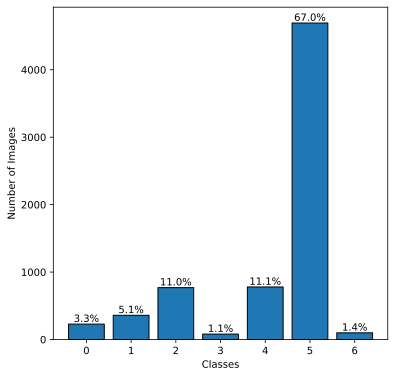

In [147]:
def plot_dataset_distribution(train_dataset, info):
    """
    Plot the distribution of classes in the dataset
    with additional statistics
    """

    all_labels = []
    for _, label in train_dataset:
        all_labels.append(label.item())
    
    all_labels = np.array(all_labels)
    classes = np.unique(all_labels)

            
    class_counts = {c: np.sum(all_labels == c) for c in classes}

    plt.figure(figsize=(6, 6))
    bars = plt.bar(range(len(classes)), 
                  [class_counts[c] for c in classes], 
                  edgecolor='black')
    
    # Add percentage labels
    for bar, count in zip(bars, [class_counts[c] for c in classes]):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{100 * count / len(all_labels):.1f}%', 
                ha='center', va='bottom')
    
    plt.xticks(range(len(classes)), [i for i in classes])
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')    

plot_dataset_distribution(train_dataset, info)

## Model

In [148]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(n_channels, n_classes)

optimizer = get_optimizer(model, lr=LR)
criterion = get_loss_function(info['task'])


Using device: cpu


In [149]:
# Only trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

# Count only top-level child modules (not counting submodules within containers like nn.Sequential)
num_layers = sum(1 for _ in model.children())
print(f"Number of top-level layers: {num_layers}")

# Count all modules (including nested)
num_all_layers = sum(1 for _ in model.modules())
print(f"Total number of modules (including nested): {num_all_layers}")

Trainable parameters: 234967
Number of top-level layers: 6
Total number of modules (including nested): 29


In [150]:
# To find the clipping parameter we use the following function
# after each loss.backward() during traning

def median_gradient_norm(model):
    norms = [p.grad.data.norm(2).item() for p in model.parameters() if p.grad is not None]
    return np.median(norms)


## Training 

In [151]:
loss_curve_train = []
loss_curve_val = []

auc_curve_train = []
auc_curve_val = []

# only for 1 initit of weights
acc_curve_train = []
acc_curve_val = []

av_epoch_time = []


gradient_norms = []

# Time tracking
total_time = 0
epoch_times = []

# For tracking metrics
loss_curve_train = []
loss_curve_val = []


for epoch in range(NUM_EPOCHS):
    train_loss = 0.0
    train_batches = 0

    # Training phase
    start_epoch_time = time.perf_counter() 

    model.train()        
    for inputs, targets in tqdm(train_loader):

        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)

        # can be used for other 2D datasets 
        if info['task'] == 'multi-label, binary-class':
            targets = targets.to(torch.float32)
            loss = criterion(outputs, targets)
        else:
            targets = targets.squeeze().long()
            loss = criterion(outputs, targets)
        
        loss.backward()
        gradient_norms.append(median_gradient_norm(model))
        optimizer.step()

        train_loss += loss.item()
        train_batches += 1

    avg_train_loss = train_loss / train_batches if train_batches > 0 else 0
    loss_curve_train.append(avg_train_loss)

    # Validation 
    model.eval()
    val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        
        for val_inputs, val_targets in val_loader:
            val_inputs = val_inputs.to(device)
            val_targets = val_targets.to(device)
            
            val_outputs = model(val_inputs)
            if info['task'] == 'multi-label, binary-class':
                val_targets = val_targets.to(torch.float32)
                v_loss = criterion(val_outputs, val_targets)
            else:
                val_targets = val_targets.squeeze().long()
                v_loss = criterion(val_outputs, val_targets)
                
            val_loss += v_loss.item()
            val_batches += 1
            
    avg_val_loss = val_loss / val_batches if val_batches > 0 else 0
    loss_curve_val.append(avg_val_loss)

    # ---- Calculate validation ACC for early stopping ----
    metric_val = scores('val', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)
    
    end_epoch_time = time.perf_counter()
    epoch_time = end_epoch_time - start_epoch_time
    epoch_times.append(epoch_time)
    total_time += epoch_time
    av_epoch_time.append(epoch_time)
    
    # we save acc and auc curves only for 1 inititalization as they don't significantly differ + evaluation takes time
    metric_train = scores('train', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)

    auc_curve_train.append(metric_train.AUC)
    acc_curve_train.append(metric_train.ACC)
    
    metric_val = scores('val', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)
    auc_curve_val.append(metric_val.AUC)
    acc_curve_val.append(metric_val.ACC)
        
    print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}, val loss: {avg_val_loss:.4f}")
    print(f"Epoch {epoch+1} training time: {epoch_time:.2f} seconds")
    

100%|███████████████████| 55/55 [00:08<00:00,  6.63it/s]


Epoch 1 train loss: 1.2908, val loss: 1.0605
Epoch 1 training time: 9.33 seconds


100%|███████████████████| 55/55 [00:08<00:00,  6.17it/s]


Epoch 2 train loss: 0.9811, val loss: 0.9215
Epoch 2 training time: 9.93 seconds


100%|███████████████████| 55/55 [00:07<00:00,  7.20it/s]


...

Epoch 98 train loss: 0.0004, val loss: 1.7638
Epoch 98 training time: 8.05 seconds


100%|███████████████████| 55/55 [00:05<00:00,  9.27it/s]


Epoch 99 train loss: 0.0003, val loss: 1.7706
Epoch 99 training time: 6.76 seconds


100%|███████████████████| 55/55 [00:06<00:00,  9.00it/s]


Epoch 100 train loss: 0.0003, val loss: 1.7836
Epoch 100 training time: 6.90 seconds


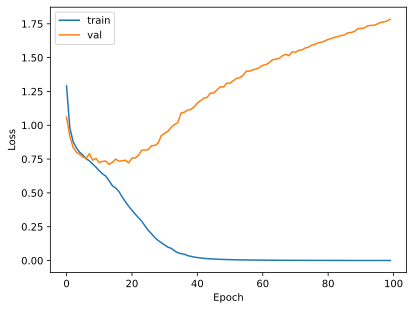

In [158]:
plt.plot(loss_curve_train, label='train')
plt.plot(loss_curve_val, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend();

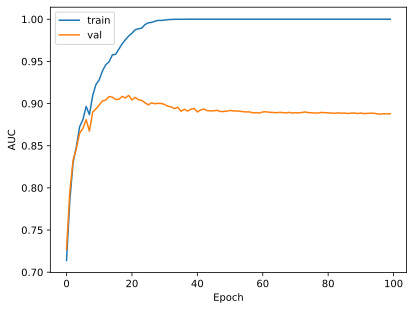

In [159]:
plt.plot(auc_curve_train, label='train')
plt.plot(auc_curve_val, label='val')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend();

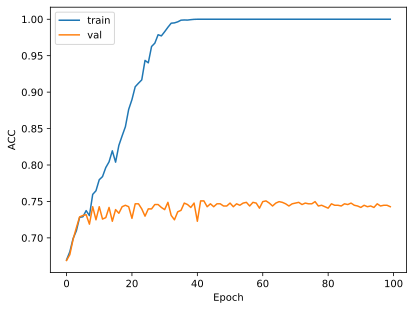

In [160]:
plt.plot(acc_curve_train, label='train')
plt.plot(acc_curve_val, label='val')
plt.xlabel('Epoch')
plt.ylabel('ACC')
plt.legend();

In [161]:
optimal_early_stopping = int((len(train_dataset)/BATCH_SIZE)*40)
C = round( np.median(gradient_norms[:optimal_early_stopping]),4)
print("Clipping parameter:", C )

Clipping parameter: 0.1984


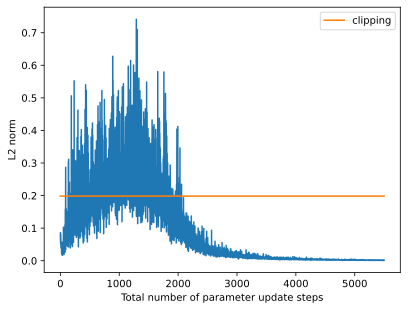

In [162]:
plt.plot(gradient_norms)
plt.plot([C]*len(gradient_norms), label='clipping');
plt.xlabel('Total number of parameter update steps')
plt.ylabel('L2 norm')
plt.legend();

## Evaluation

In [163]:
print('==> Evaluating ...')
final_auc_train = []
final_acc_train = []

final_auc_test = []
final_acc_test = []

model.eval()
metric_train = scores('train', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)

final_auc_train = metric_train.AUC 
final_acc_train = metric_train.ACC

metric_test = scores('test', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)
    
final_auc_test = metric_test.AUC 
final_acc_test = metric_test.ACC 
    
print("--------------------------------------------------")  
print(f"Learning Rate: {LR}")
print(f"Total training time: {total_time:.2f} seconds")
print(f"Average epoch time: {np.mean(av_epoch_time):.2f} ± {np.std(av_epoch_time):.2f} seconds")
print(f"Clipping: {C}")

print("--------------------------------------------------")
print(f"ACC (train): {final_acc_train:.4f}") 
print(f"AUC (train): {final_auc_train:.4f}") 
print("--------------------------------------------------")
print(f"ACC (test): {final_acc_test:.4f}") 
print(f"AUC (test): {final_auc_test:.4f}") 



==> Evaluating ...
--------------------------------------------------
Learning Rate: 0.0001
Total training time: 704.34 seconds
Average epoch time: 7.04 ± 1.00 seconds
Clipping: 0.1984
--------------------------------------------------
ACC (train): 1.0000
AUC (train): 1.0000
--------------------------------------------------
ACC (test): 0.7297
AUC (test): 0.8966


#### Results 

```
--------------------------------------------------
Learning Rate: 0.0001
Total training time: 704.34 seconds
Average epoch time: 7.04 ± 1.00 seconds
Clipping: 0.1984
--------------------------------------------------
ACC (train): 1.0000
AUC (train): 1.0000
--------------------------------------------------
ACC (test): 0.7297
AUC (test): 0.8966

--------------------------------------------------
Learning Rate: 0.0005
Total training time: 809.86 seconds
Average epoch time: 8.10 ± 0.72 seconds
Clipping: 0.1446
--------------------------------------------------
ACC (train): 1.0000
AUC (train): 1.0000
--------------------------------------------------
ACC (test): 0.7406
AUC (test): 0.9099

--------------------------------------------------
Learning Rate: 0.001
Total training time: 814.04 seconds
Average epoch time: 8.14 ± 0.78 seconds
Clipping: 0.1259
--------------------------------------------------
ACC (train): 1.0000
AUC (train): 1.0000
--------------------------------------------------
ACC (test): 0.7441
AUC (test): 0.9091

--------------------------------------------------
Learning Rate: 0.01
Total training time: 772.47 seconds
Average epoch time: 7.72 ± 1.02 seconds
Clipping: 0.0599
--------------------------------------------------
ACC (train): 0.9880
AUC (train): 0.9996
--------------------------------------------------
ACC (test): 0.6993
AUC (test): 0.8554

Learning Rate: 0.1
Total training time: 679.50 seconds
Average epoch time: 6.80 ± 0.54 seconds
Clipping: 0.0
--------------------------------------------------
ACC (train): 0.6698
AUC (train): 0.5000
--------------------------------------------------
ACC (test): 0.6688
AUC (test): 0.5000
```

